In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from projectlib.encoding import Ordinal_Encoder

# Daten laden
candidate_paths = [
    Path("adult.data"),
    Path.cwd() / "adult.data",
    Path.cwd().parent / "adult.data",
    Path.cwd().parent / "data" / "adult.data",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Die Datei adult.data wurde nicht gefunden.")

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(data_path, header=None, names=column_names, na_values="?", keep_default_na=False)

# 1. Whitespaces entfernen, da Strings oft fälschlicherweise " ?" statt "?" enthalten
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()

# 2. '?' durch ein sauberes, ökonomisch interpretierbares Label ersetzen
df = df.replace("?", "Unknown")

# Kurzer Check, ob es geklappt hat:
print("fehlende Werte in workclass:", (df['workclass'] == 'Unknown').sum())

fehlende Werte in workclass: 1836


C:\Users\User\AppData\Local\Temp\ipykernel_17412\785625185.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


In [2]:
from projectlib.encoding import Ordinal_Encoder

# Ordinal Encoding für education, damit die spätere Analyse eine sinnvolle Rangordnung hat
education_order = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
    "Prof-school", "Doctorate"
]

df["education_ordinal"] = Ordinal_Encoder(
    df[["education"]].copy(),
    "education",
    categories_order=[education_order],
    starting_numbers=[1],
    step_sizes=[1],
)["education"]

print(df[["education", "education_ordinal"]].head(10))

   education  education_ordinal
0  Bachelors                 13
1  Bachelors                 13
2    HS-grad                  9
3       11th                  7
4  Bachelors                 13
5    Masters                 14
6        9th                  5
7    HS-grad                  9
8    Masters                 14
9  Bachelors                 13


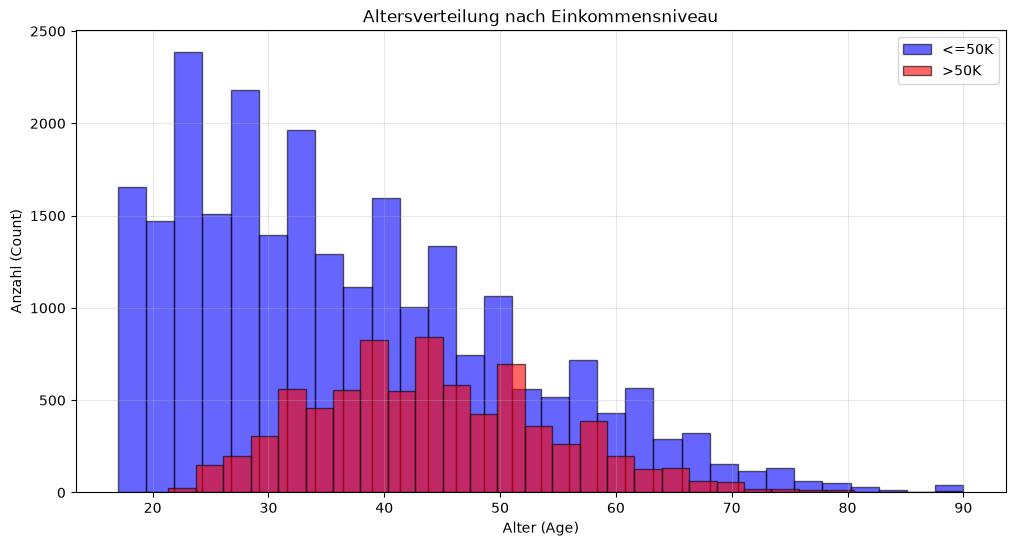

Personen mit <=50K: 24720
Personen mit >50K: 7841


In [3]:
# Histogram: Alter vs. Einkommen
plt.figure(figsize=(12, 6))

# Separate data by income
under_50k = df[df['income'].str.strip() == '<=50K']['age']
over_50k = df[df['income'].str.strip() == '>50K']['age']

# Create histogram
plt.hist(under_50k, bins=30, alpha=0.6, label='<=50K', color='blue', edgecolor='black')
plt.hist(over_50k, bins=30, alpha=0.6, label='>50K', color='red', edgecolor='black')

plt.xlabel('Alter (Age)')
plt.ylabel('Anzahl (Count)')
plt.title('Altersverteilung nach Einkommensniveau')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print counts
print(f"Personen mit <=50K: {len(under_50k)}")
print(f"Personen mit >50K: {len(over_50k)}")

In [4]:
# Kardinalität bestimmen
categorical_cols = df.select_dtypes(include=['object']).columns.drop('income') # ohne das Target

for col in categorical_cols:
    print(f"Feature: {col:15} | einzigartige Kategorien: {df[col].nunique()}")

Feature: workclass       | einzigartige Kategorien: 9
Feature: education       | einzigartige Kategorien: 16
Feature: marital_status  | einzigartige Kategorien: 7
Feature: occupation      | einzigartige Kategorien: 15
Feature: relationship    | einzigartige Kategorien: 6
Feature: race            | einzigartige Kategorien: 5
Feature: sex             | einzigartige Kategorien: 2
Feature: native_country  | einzigartige Kategorien: 42


C:\Users\User\AppData\Local\Temp\ipykernel_20108\2815492371.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop('income') # ohne das Target


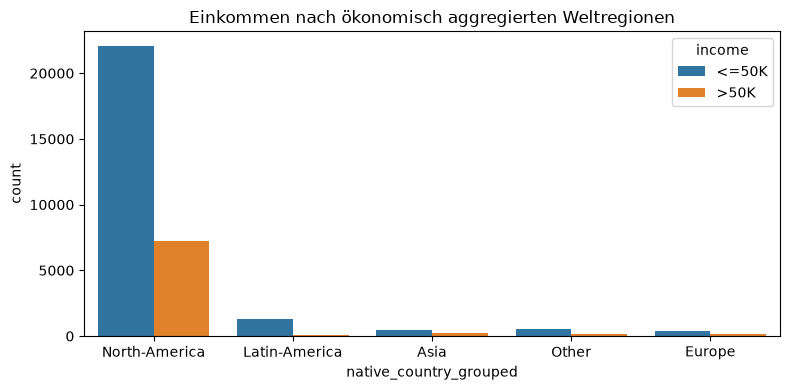

In [5]:
def aggregate_countries(country):
    if country in ['United-States', 'Canada']:
        return 'North-America'
    elif country in ['Mexico', 'Puerto-Rico', 'Cuba', 'Honduras', 'Jamaica', 'Columbia', 'Dominican-Republic', 'El-Salvador', 'Guatemala', 'Haiti', 'Nicaragua', 'Peru', 'Ecuador', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)']:
        return 'Latin-America'
    elif country in ['Germany', 'England', 'Italy', 'Poland', 'Portugal', 'France', 'Yugoslavia', 'Scotland', 'Greece', 'Ireland', 'Hungary', 'Holand-Netherlands']:
        return 'Europe'
    elif country in ['Philippines', 'India', 'China', 'Japan', 'Vietnam', 'Taiwan', 'Hong', 'Cambodia', 'Laos', 'Thailand', 'Iran']:
        return 'Asia'
    else:
        return 'Other'

df['native_country_grouped'] = df['native_country'].apply(aggregate_countries)

# Visualisierung des Effekts
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='native_country_grouped', hue='income', order=df['native_country_grouped'].value_counts().index)
plt.title("Einkommen nach ökonomisch aggregierten Weltregionen")
plt.tight_layout()
plt.show()


    education_ordinal     education  income_above_50k
14                  1     Preschool          0.000000
13                  2       1st-4th          0.035714
11                  3       5th-6th          0.048048
8                   4       7th-8th          0.061920
4                   5           9th          0.052529
12                  6          10th          0.066452
2                   7          11th          0.051064
15                  8          12th          0.076212
1                   9       HS-grad          0.159509
5                  10  Some-college          0.190235
7                  11     Assoc-voc          0.261216
6                  12    Assoc-acdm          0.248360
0                  13     Bachelors          0.414753
3                  14       Masters          0.556587
10                 15   Prof-school          0.734375
9                  16     Doctorate          0.740920


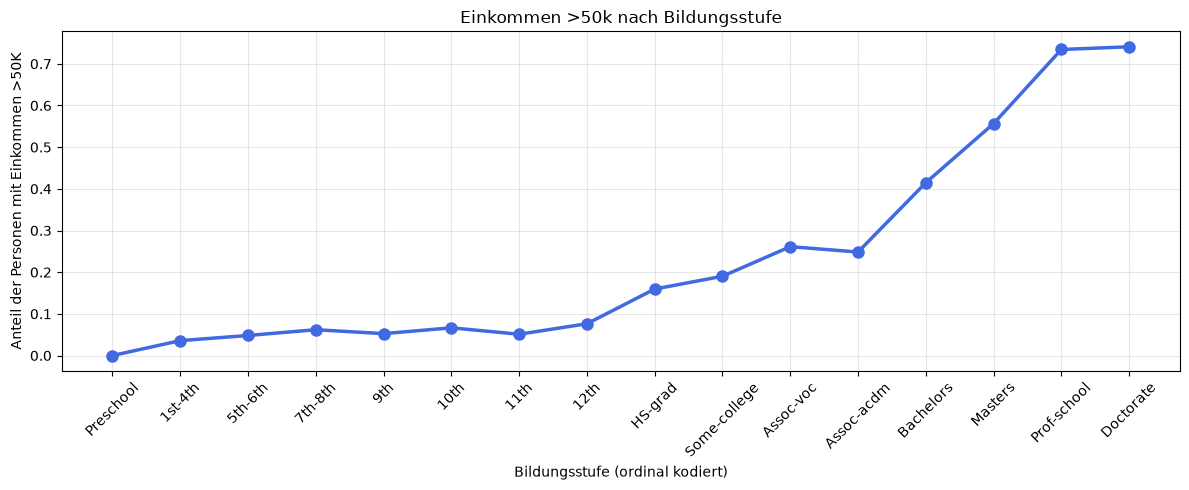

In [6]:
# Für die Variable education ist der Ordinal Encoder geeignet, 
# da die Bildungsstufen eine natürliche, monotone Rangordnung aufweisen. 
# Dadurch kann die Reihenfolge der Bildungsniveaus erhalten bleiben, ohne die Variable in mehrere binäre Spalten zu zerlegen.

plot_df = df.copy()
plot_df['education'] = plot_df['education'].astype(str).str.strip()
plot_df['income'] = plot_df['income'].astype(str).str.strip()
plot_df['education_ordinal'] = plot_df['education_ordinal'].astype(int)
plot_df = plot_df[plot_df['education'].isin(education_order)].copy()
plot_df['income_above_50k'] = (plot_df['income'] == '>50K').astype(int)

summary = (
    plot_df.groupby(['education_ordinal', 'education'], sort=False)['income_above_50k']
    .mean()
    .reset_index()
    .sort_values('education_ordinal')
)

print(summary)

# Visualisierung als Linie mit Punkten auf Basis der ordinal kodierten Bildungsstufe

plt.figure(figsize=(12, 5))
plt.plot(summary['education_ordinal'], summary['income_above_50k'], marker='o', linestyle='-', color='royalblue', linewidth=2.5, markersize=8)
plt.xticks(summary['education_ordinal'], summary['education'], rotation=45)
plt.xlabel('Bildungsstufe (ordinal kodiert)')
plt.ylabel('Anteil der Personen mit Einkommen >50K')
plt.title('Einkommen >50k nach Bildungsstufe')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Diagnose der Einkommen-Werte
print(df['income'].head().tolist())
print('\nEinzigartige Einkommen-Werte:')
print(df['income'].astype(str).unique()[:10])

['<=50K', '<=50K', '<=50K', '<=50K', '<=50K']

Einzigartige Einkommen-Werte:
<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [9]:

# Diagnose: Welche Bildungsstufen sind wirklich in den Daten vorhanden?
education_summary = df.groupby('education')['age'].mean()
print(df['education'].value_counts().to_string())
print('\nAnzahl der Zeilen mit education:', df['education'].notna().sum())
print('\neducation_summary:')
print(education_summary)

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51

Anzahl der Zeilen mit education: 32561

education_summary:
education
10th            37.429796
11th            32.355745
12th            32.000000
1st-4th         46.142857
5th-6th         42.885886
7th-8th         48.445820
9th             41.060311
Assoc-acdm      37.381443
Assoc-voc       38.553546
Bachelors       38.904949
Doctorate       47.702179
HS-grad         38.974479
Masters         44.049913
Preschool       42.764706
Prof-school     44.746528
Some-college    35.756275
Name: age, dtype: float64


In [10]:
from projectlib.encoding import One_Hot_Encoder

# 1. Vorbereitung: aggregierte Ländergruppen erzeugen
if "native_country_grouped" not in df.columns:
    def aggregate_countries(country):
        if country in ["United-States", "Canada"]:
            return "North-America"
        elif country in ["Mexico", "Puerto-Rico", "Cuba", "Honduras", "Jamaica", "Columbia",
                         "Dominican-Republic", "El-Salvador", "Guatemala", "Haiti",
                         "Nicaragua", "Peru", "Ecuador", "Trinadad&Tobago",
                         "Outlying-US(Guam-USVI-etc)"]:
            return "Latin-America"
        elif country in ["Germany", "England", "Italy", "Poland", "Portugal", "France",
                         "Yugoslavia", "Scotland", "Greece", "Ireland", "Hungary",
                         "Holand-Netherlands"]:
            return "Europe"
        elif country in ["Philippines", "India", "China", "Japan", "Vietnam", "Taiwan",
                         "Hong", "Cambodia", "Laos", "Thailand", "Iran"]:
            return "Asia"
        else:
            return "Other"

    df["native_country_grouped"] = df["native_country"].apply(aggregate_countries)

# 2. One-Hot-Encoding der kategorialen Features
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
df_ohe = One_Hot_Encoder(df.copy(), one_hot_features, delete_old_column=True)

# 3. Ausgabe der erzeugten Features
one_hot_columns = [col for col in df_ohe.columns if any(col.startswith(f"{feature}_") for feature in one_hot_features)]
print("Erzeugte One-Hot-Features:")
print(one_hot_columns)

Erzeugte One-Hot-Features:
['marital_status_Never-married', 'marital_status_Married-civ-spouse', 'marital_status_Divorced', 'marital_status_Married-spouse-absent', 'marital_status_Separated', 'marital_status_Married-AF-spouse', 'marital_status_Widowed', 'relationship_Not-in-family', 'relationship_Husband', 'relationship_Wife', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Other-relative', 'race_White', 'race_Black', 'race_Asian-Pac-Islander', 'race_Amer-Indian-Eskimo', 'race_Other', 'sex_Male', 'sex_Female', 'workclass_State-gov', 'workclass_Self-emp-not-inc', 'workclass_Private', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Unknown', 'workclass_Self-emp-inc', 'workclass_Without-pay', 'workclass_Never-worked', 'native_country_grouped_North-America', 'native_country_grouped_Latin-America', 'native_country_grouped_Asia', 'native_country_grouped_Other', 'native_country_grouped_Europe']


In [11]:
from projectlib.encoding import Target_Encoder

# Vergleich: Wie gut sind workclass und occupation als Target-Encoding-Features?
# Das Ziel ist nicht, ein Modell zu trainieren, sondern zu sehen, ob die Kategorien
# sich klar in unterschiedliche Zielraten unterscheiden.
income_target = df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})


def summarize_target_encoding(feature_name):
    tmp = df[[feature_name, "income"]].copy()
    tmp["income_target"] = income_target
    summary = (
        tmp.groupby(feature_name)["income_target"]
        .agg(["count", "mean"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    summary["mean"] = summary["mean"].round(3)
    return summary

workclass_summary = summarize_target_encoding("workclass")
occupation_summary = summarize_target_encoding("occupation")

print("Workclass - Target-Encoding Übersicht")
print(workclass_summary.head(10))
print("\nOccupation - Target-Encoding Übersicht")
print(occupation_summary.head(10))

print("\nVergleich der Unterschiedlichkeit der Kategorie-Mittelwerte:")
print(f"workclass: Spannweite der Mittelwerte = {workclass_summary['mean'].max() - workclass_summary['mean'].min():.3f}")
print(f"occupation: Spannweite der Mittelwerte = {occupation_summary['mean'].max() - occupation_summary['mean'].min():.3f}")


Workclass - Target-Encoding Übersicht
          workclass  count   mean
4      Self-emp-inc   1116  0.557
0       Federal-gov    960  0.386
1         Local-gov   2093  0.295
5  Self-emp-not-inc   2541  0.285
6         State-gov   1298  0.272
3           Private  22696  0.219
7           Unknown   1836  0.104
2      Never-worked      7  0.000
8       Without-pay     14  0.000

Occupation - Target-Encoding Übersicht
           occupation  count   mean
3     Exec-managerial   4066  0.484
9      Prof-specialty   4140  0.449
10    Protective-serv    649  0.325
12       Tech-support    928  0.305
11              Sales   3650  0.269
2        Craft-repair   4099  0.227
13   Transport-moving   1597  0.200
0        Adm-clerical   3770  0.134
6   Machine-op-inspct   2002  0.125
4     Farming-fishing    994  0.116

Vergleich der Unterschiedlichkeit der Kategorie-Mittelwerte:
workclass: Spannweite der Mittelwerte = 0.557
occupation: Spannweite der Mittelwerte = 0.477


Erklärte Varianz pro Hauptkomponente:
[0.11109605 0.0662094 ]


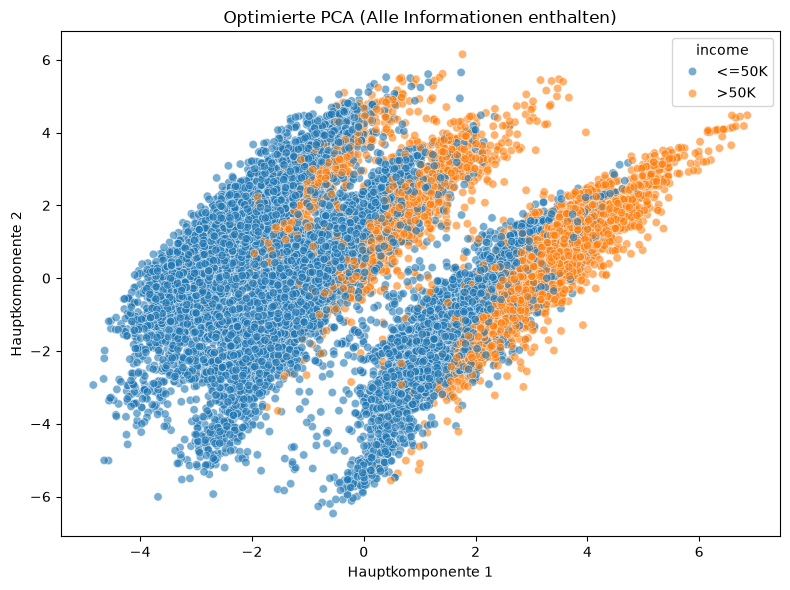

In [12]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 0. Pfad-Setup für die Library
root = Path.cwd()
for candidate in [root, root.parent, root.parent.parent]:
    if (candidate / "projectlib").exists():
        sys.path.insert(0, str(candidate))
        break

# Nutzt die sauberen Encoder aus dem Hauptverzeichnis
from projectlib.encoding import One_Hot_Encoder, Ordinal_Encoder, Target_Encoder

# --- 1. BASISDATEN & TARGET VORBEREITEN ---
pca_df = df.copy()
pca_df["income_target"] = pca_df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# --- 2. ENCODING DER KATEGORIELLEN SPALTEN ---

# Ordinal Encoding für education
pca_df["education_ordinal"] = Ordinal_Encoder(
    pca_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_numbers=[1],
    step_sizes=[1],
)["education"]

# Target Encoding für workclass und occupation (bevor One-Hot die Originalspalten verändert)
target_encoded_cols = Target_Encoder(
    pca_df[["workclass", "occupation", "income_target"]],
    ["workclass", "occupation"],
    "income_target"
)
pca_df["workclass_target"] = target_encoded_cols["workclass_target"]
pca_df["occupation_target"] = target_encoded_cols["occupation_target"]

# One-Hot Encoding für alle nominalen Features (erzeugt X_... Spalten)
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
pca_df = One_Hot_Encoder(pca_df, one_hot_features, delete_old_column=True)


# --- 3. AUTOMATISCHE FEATURE-AUSWAHL (KEIN INFORMATIONSVERLUST!!) ---
# Wir definieren die Basis-Features manuell
feature_columns = [
    "age", "education_ordinal", "education_num", "capital_gain", "capital_loss",
    "hours_per_week", "income_target", "workclass_target", "occupation_target"
]

# Füge alle Spalten hinzu, die durch das One-Hot-Encoding entstanden sind,
# aber schließe die aus, die auf "_target" enden (um Duplikate zu verhindern)!
one_hot_spalten = [
    col for col in pca_df.columns 
    if any(col.startswith(f"{f}_") for f in one_hot_features) 
    and not col.endswith("_target") ]

feature_columns.extend(one_hot_spalten)

# Datenmatrix für PCA extrahieren
X = pca_df[feature_columns].astype(float)


# --- 4. PCA & VISUALISIERUNG ---
# Standardisieren
X_scaled = StandardScaler().fit_transform(X)

# PCA auf 2 Komponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz pro Hauptkomponente:")
print(pca.explained_variance_ratio_)

# Ergebnisse plotten
pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_result["income"] = pca_df["income"].astype(str).str.strip()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("Optimierte PCA (Alle Informationen enthalten)")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()

Erklärte Varianz pro Hauptkomponente:
[0.11295561 0.07572769]


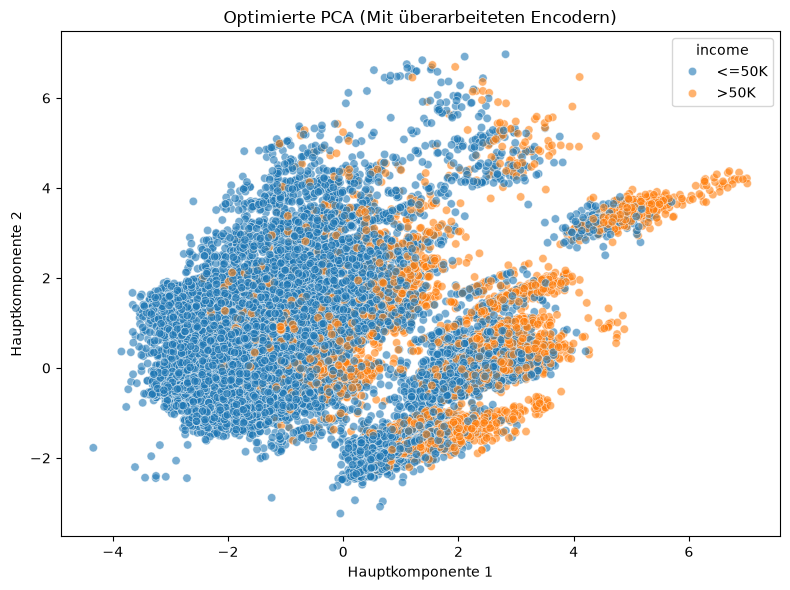

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# 0. Pfad-Setup für die Library
root = Path.cwd()
for candidate in [root, root.parent, root.parent.parent]:
    if (candidate / "projectlib").exists():
        sys.path.insert(0, str(candidate))
        break

# Hier nutzen wir jetzt konsequent deine überarbeitete Version!
from projectlib.alternativeEncoding import (
    One_Hot_Encoder, 
    Ordinal_Encoder, 
    Target_Encoder_Fit, 
    Target_Encoder_Transform
)
# Daten laden
candidate_paths = [
    Path("adult.data"),
    Path.cwd() / "adult.data",
    Path.cwd().parent / "adult.data",
    Path.cwd().parent / "data" / "adult.data",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Die Datei adult.data wurde nicht gefunden.")

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income" ]

df = pd.read_csv(data_path, header=None, names=column_names, na_values="?", keep_default_na=False, skipinitialspace=True)
# Direkt nach pd.read_csv einfügen:
#df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


# --- 1. BASISDATEN & TARGET VORBEREITEN ---
pca_df = df.copy()
pca_df["income_target"] = pca_df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# --- 2. ENCODING MIT DEN NEUEN METHODEN ---

# Ordinal Encoding für education
pca_df["education_ordinal"] = Ordinal_Encoder(
    pca_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_number=1,
    step_size=1,
)["education"]

# Target Encoding (Jetzt mit expliziten Parameter-Namen, passend zu deiner Funktion)
target_mappings = Target_Encoder_Fit(
    X_train=pca_df,
    y_train=pca_df["income_target"],
    columns_to_be_encoded=["workclass", "occupation"]
)

encoded_target_df = Target_Encoder_Transform(
    pca_df[["workclass", "occupation"]],
    ["workclass", "occupation"],
    target_mappings
)

# Die neuen Target-Spalten sauber ins DataFrame schreiben
pca_df["workclass_target"] = encoded_target_df["workclass_target"]
pca_df["occupation_target"] = encoded_target_df["occupation_target"]

# Die aggregierten Länder in Regionen zusammenfassenm, um die Kardinalität zu reduzieren
pca_df["native_country_grouped"] = pca_df["native_country"].astype(str).str.strip().apply(
    lambda x: "United-States" if x == "United-States" else "Other"
)

# One-Hot Encoding für alle nominalen Features (ohne das nicht existierende Argument)
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
pca_df = One_Hot_Encoder(pca_df, one_hot_features)

# --- 3. AUTOMATISCHE FEATURE-AUSWAHL (OHNE DUPLIKATE) ---
feature_columns = [
    "age", "education_ordinal", "education_num", "capital_gain", "capital_loss",
    "hours_per_week", "workclass_target", "occupation_target" 
]

# Dynamisch die One-Hot-Spalten einsammeln, aber die '_target'-Endungen ignorieren
one_hot_spalten = [
    col for col in pca_df.columns 
    if any(col.startswith(f"{f}_") for f in one_hot_features) 
    and not col.endswith("_target")
]
feature_columns.extend(one_hot_spalten)

# Datenmatrix extrahieren
X = pca_df[feature_columns].astype(float)


# PCA & VISUALISIERUNG 
# Standardisieren
X_scaled = StandardScaler().fit_transform(X)

# PCA auf 2 Komponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz pro Hauptkomponente:")
print(pca.explained_variance_ratio_)

# Ergebnisse plotten
pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_result["income"] = pca_df["income"].astype(str).str.strip()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("Optimierte PCA (Mit überarbeiteten Encodern)")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()



In [ ]:
#still not ideal PCA leads to ~20% variance explained by the first two components.
#suspecting that the one-hot encoder is causing to much sparsity for the PCA to bne conclusive  
#we have to keep simplify the data and reduce the number of features!


Erklärte Varianz pro Hauptkomponente:
[0.15266299 0.09501951]
Gesamte erklärte Varianz der 2 Komponenten: 0.2477


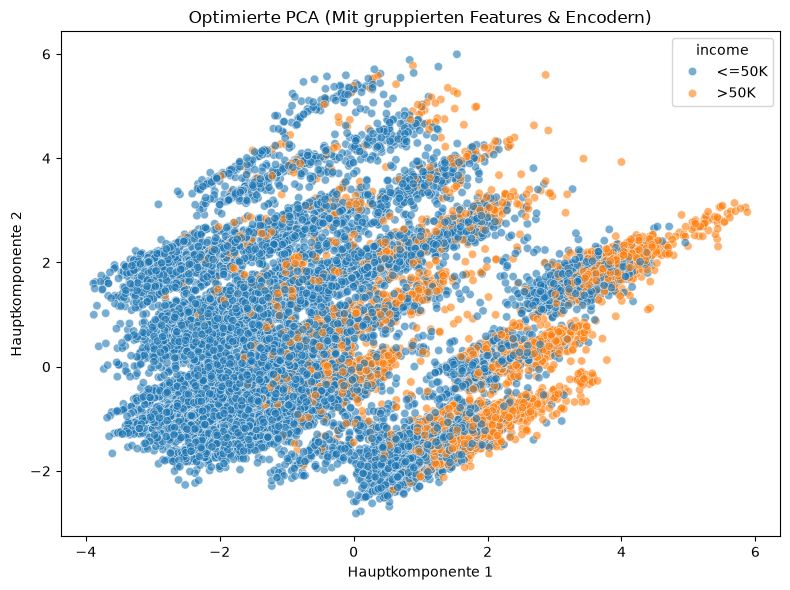

In [19]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 0. Pfad-Setup für die Library
root = Path.cwd()
for candidate in [root, root.parent, root.parent.parent]:
    if (candidate / "projectlib").exists():
        sys.path.insert(0, str(candidate))
        break


from projectlib.alternativeEncoding import (
    One_Hot_Encoder, 
    Ordinal_Encoder, 
    Target_Encoder_Fit, 
    Target_Encoder_Transform
)

# Daten laden
candidate_paths = [
    Path("adult.data"),
    Path.cwd() / "adult.data",
    Path.cwd().parent / "adult.data",
    Path.cwd().parent / "data" / "adult.data",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Die Datei adult.data wurde nicht gefunden.")

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(data_path, header=None, names=column_names, na_values="?", keep_default_na=False, skipinitialspace=True)


# --- 1. BASISDATEN & TARGET VORBEREITEN ---
pca_df = df.copy()
pca_df["income_target"] = pca_df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})


# --- 1.5 FEATURE ENGINEERING & GRUPPIERUNG ---

# A) Marital Status sinnvoll bündeln
marital_mapping = {
    'Married-civ-spouse': 'married',
    'Married-AF-spouse': 'married',
    'Married-spouse-absent': 'married',
    'Never-married': 'never-married',
    'Divorced': 'separated_divorced_widowed',
    'Separated': 'separated_divorced_widowed',
    'Widowed': 'separated_divorced_widowed'
}
pca_df['marital_status'] = pca_df['marital_status'].astype(str).str.strip().map(marital_mapping)

# B) Workclass sinnvoll bündeln
workclass_mapping = {
    'Private': 'private',
    'Self-emp-not-inc': 'self-employed',
    'Self-emp-inc': 'self-employed',
    'Local-gov': 'government',
    'State-gov': 'government',
    'Federal-gov': 'government',
    'Without-pay': 'other/unknown',
    'Never-worked': 'other/unknown'
}
pca_df['workclass'] = pca_df['workclass'].astype(str).str.strip().map(workclass_mapping).fillna('other/unknown')

# C) Herkunftsland bündeln (Verhindert Spalten-Explosion)
pca_df["native_country_grouped"] = pca_df["native_country"].astype(str).str.strip().apply(
    lambda x: "United-States" if x == "United-States" else "Other"
)


# --- 2. ENCODING MIT DEN NEUEN METHODEN ---

# Ordinal Encoding für education
pca_df["education_ordinal"] = Ordinal_Encoder(
    pca_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_number=1,
    step_size=1,
)["education"]

# Target Encoding für workclass und occupation
target_mappings = Target_Encoder_Fit(
    X_train=pca_df,
    y_train=pca_df["income_target"],
    columns_to_be_encoded=["workclass", "occupation"]
)

encoded_target_df = Target_Encoder_Transform(
    pca_df[["workclass", "occupation"]],
    ["workclass", "occupation"],
    target_mappings
)

# Die neuen Target-Spalten sauber ins DataFrame schreiben
pca_df["workclass_target"] = encoded_target_df["workclass_target"]
pca_df["occupation_target"] = encoded_target_df["occupation_target"]

# One-Hot Encoding für alle nominalen Features (Jetzt mit den gruppierten Spalten)
one_hot_features = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
pca_df = One_Hot_Encoder(pca_df, one_hot_features)


# --- 3. AUTOMATISCHE FEATURE-AUSWAHL (OHNE DUPLIKATE) ---
# Hinweis: income_target wurde hier entfernt, da es das Ziel-Label ist!
feature_columns = [
    "age", "education_ordinal", "education_num", "capital_gain", "capital_loss",
    "hours_per_week", "workclass_target", "occupation_target"
]

# Dynamisch die One-Hot-Spalten einsammeln, aber die '_target'-Endungen ignorieren
one_hot_spalten = [
    col for col in pca_df.columns 
    if any(col.startswith(f"{f}_") for f in one_hot_features) 
    and not col.endswith("_target")
]
feature_columns.extend(one_hot_spalten)

# Datenmatrix extrahieren
X = pca_df[feature_columns].astype(float)


# --- 4. PCA & VISUALISIERUNG ---
# Standardisieren
X_scaled = StandardScaler().fit_transform(X)

# PCA auf 2 Komponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz pro Hauptkomponente:")
print(pca.explained_variance_ratio_)
print(f"Gesamte erklärte Varianz der 2 Komponenten: {sum(pca.explained_variance_ratio_):.4f}")

# Ergebnisse plotten
pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_result["income"] = pca_df["income"].astype(str).str.strip()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("Optimierte PCA (Mit gruppierten Features & Encodern)")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()

In [ ]:
#aufgeklärte Varainz bei ~25%. wir können aber dennoch einen Trend beobachten, die erste Hauptkomponente trennt 
# die beiden Einkommensgruppen relativ gut aus
#es ist bereits eine logische struktur erkennbar

=== ERGEBNISSE DER SPARSITY-BEKÄMPFUNG ===
Erklärte Varianz pro Hauptkomponente:
[0.23356302 0.12425563]
Gesamte erklärte Varianz (Ziel > 30%+): 0.3578


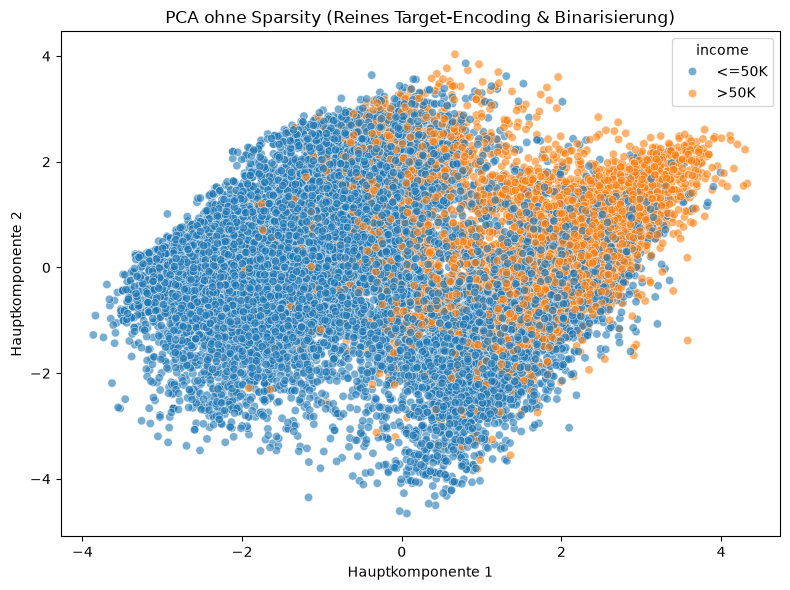

In [ ]:

# SEPERATE OPTIMIERUNGS-ZELLE: TARGET ENCODING & BINARISIERUNG GEGEN SPARSITY

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. KOPIE & TARGET VORBEREITEN ---
v2_df = df.copy()
v2_df["income_target"] = v2_df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# --- 2. LOGISCHE FEATURE-GRUPPIERUNG ---
marital_mapping = {
    'Married-civ-spouse': 'married', 'Married-AF-spouse': 'married', 'Married-spouse-absent': 'married',
    'Never-married': 'never-married',
    'Divorced': 'separated_divorced_widowed', 'Separated': 'separated_divorced_widowed', 'Widowed': 'separated_divorced_widowed'
}
v2_df['marital_status'] = v2_df['marital_status'].astype(str).str.strip().map(marital_mapping)

workclass_mapping = {
    'Private': 'private', 'Self-emp-not-inc': 'self-employed', 'Self-emp-inc': 'self-employed',
    'Local-gov': 'government', 'State-gov': 'government', 'Federal-gov': 'government',
    'Without-pay': 'other/unknown', 'Never-worked': 'other/unknown'
}
v2_df['workclass'] = v2_df['workclass'].astype(str).str.strip().map(workclass_mapping).fillna('other/unknown')

v2_df["native_country_grouped"] = v2_df["native_country"].astype(str).str.strip().apply(
    lambda x: "United-States" if x == "United-States" else "Other"
)

# --- 3. BINARISIERUNG GEGEN NUMERISCHE SPARSITY (Kapitalerträge) ---
# Statt Nullen zu loggen, machen wir eine Ja/Nein-Aussage daraus (1.0 oder 0.0)
v2_df["has_capital_gain"] = (v2_df["capital_gain"].astype(float) > 0).astype(float)
v2_df["has_capital_loss"] = (v2_df["capital_loss"].astype(float) > 0).astype(float)

# --- 4. ORDINAL ENCODING (Bildung) ---
v2_df["education_ordinal"] = Ordinal_Encoder(
    v2_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]],
    starting_number=1,
    step_size=1,
)["education"]

# --- 5. REINES TARGET ENCODING FÜR ALLE NOMINALEN FEATURES ---
# Keine One-Hot-Spalten mehr! Jedes kategoriale Feature bleibt genau EINE Spalte.
nominal_features = ["marital_status", "relationship", "race", "sex", "workclass", "occupation", "native_country_grouped"]

target_mappings_v2 = Target_Encoder_Fit(
    X_train=v2_df,
    y_train=v2_df["income_target"],
    columns_to_be_encoded=nominal_features
)

encoded_nominal_df = Target_Encoder_Transform(
    v2_df[nominal_features],
    nominal_features,
    target_mappings_v2
)

# Übertrag der encodierten Target-Spalten in das Haupt-DataFrame
for col in nominal_features:
    v2_df[f"{col}_target"] = encoded_nominal_df[f"{col}_target"]

# --- 6. SAUBERE FEATURE-AUSWAHL FÜR DIE PCA (KEINE SPARSITY) ---
feature_columns_v2 = [
    "age", "education_ordinal", "education_num", "hours_per_week",
    "has_capital_gain", "has_capital_loss"
]
# Dynamisch die neuen Target-Spalten hinzufügen
feature_columns_v2.extend([f"{col}_target" for col in nominal_features])

# Datenmatrix extrahieren (Jede Spalte enthält nun echte, dichte Fließkommazahlen)
X_v2 = v2_df[feature_columns_v2].astype(float)

# --- 7. PCA & VISUALISIERUNG ---
X_scaled_v2 = StandardScaler().fit_transform(X_v2)

pca_v2 = PCA(n_components=2)
X_pca_v2 = pca_v2.fit_transform(X_scaled_v2)

print(" ERGEBNISSE DER SPARSITY-BEKÄMPFUNG")
print("Erklärte Varianz pro Hauptkomponente:")
print(pca_v2.explained_variance_ratio_)
print(f"Gesamte erklärte Varianz (Ziel > 30%+): {sum(pca_v2.explained_variance_ratio_):.4f}")

# Plotten
pca_result_v2 = pd.DataFrame(X_pca_v2, columns=["PC1", "PC2"])
pca_result_v2["income"] = v2_df["income"].astype(str).str.strip()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_result_v2, x="PC1", y="PC2", hue="income", alpha=0.6)
plt.title("PCA ohne Sparsity (Reines Target-Encoding & Binarisierung)")
plt.xlabel("Hauptkomponente 1")
plt.ylabel("Hauptkomponente 2")
plt.tight_layout()
plt.show()

In [ ]:
#dieses vereinfachte Model lässt sich deutlich besser erklären, mann sieht dass für die HK 1 und HK2 >0 sich ein cluster bildet
#aber die features wurden deutlich vereinfacht 
#das echte Problem aber ist dass das Model im gewisse Sinne overfitted wird
#insbesondere weil man das target-encoding auf dem ganzen Datensatz gemacht hat und nicht nur auf dem Trainingsdatensatz
#--> Data Leakage!

In [ ]:
#Um die Unterschiede der beiden PCA-Ansatze zu verstehen studieren wir die PCA loadings und die Feature-Importance

In [ ]:
# ==============================================================================
# UNABHÄNGIGE ZELLE: PCA LOADINGS FÜR DIE VERSION MIT ONE-HOT-ENCODING
# ==============================================================================
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- CODE AUS DEINER VORLAGE AUSFÜHREN ---
root = Path.cwd()
for candidate in [root, root.parent, root.parent.parent]:
    if (candidate / "projectlib").exists():
        sys.path.insert(0, str(candidate))
        break

from projectlib.alternativeEncoding import (
    One_Hot_Encoder, Ordinal_Encoder, Target_Encoder_Fit, Target_Encoder_Transform
)

candidate_paths = [Path("adult.data"), Path.cwd() / "adult.data", Path.cwd().parent / "adult.data"]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Die Datei adult.data wurde nicht gefunden.")

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", 
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss", 
    "hours_per_week", "native_country", "income"
]
df_mid = pd.read_csv(data_path, header=None, names=column_names, na_values="?", keep_default_na=False, skipinitialspace=True)

pca_df_mid = df_mid.copy()
pca_df_mid["income_target"] = pca_df_mid["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# Gruppierungen
marital_mapping = {
    'Married-civ-spouse': 'married', 'Married-AF-spouse': 'married', 'Married-spouse-absent': 'married',
    'Never-married': 'never-married', 'Divorced': 'separated_divorced_widowed', 'Separated': 'separated_divorced_widowed', 'Widowed': 'separated_divorced_widowed'
}
pca_df_mid['marital_status'] = pca_df_mid['marital_status'].astype(str).str.strip().map(marital_mapping)

workclass_mapping = {
    'Private': 'private', 'Self-emp-not-inc': 'self-employed', 'Self-emp-inc': 'self-employed',
    'Local-gov': 'government', 'State-gov': 'government', 'Federal-gov': 'government', 'Without-pay': 'other/unknown', 'Never-worked': 'other/unknown'
}
pca_df_mid['workclass'] = pca_df_mid['workclass'].astype(str).str.strip().map(workclass_mapping).fillna('other/unknown')

pca_df_mid["native_country_grouped"] = pca_df_mid["native_country"].astype(str).str.strip().apply(
    lambda x: "United-States" if x == "United-States" else "Other"
)

# Encodings
pca_df_mid["education_ordinal"] = Ordinal_Encoder(
    pca_df_mid[["education"]].copy(), "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th", "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters", "Prof-school", "Doctorate"]],
    starting_number=1, step_size=1
)["education"]

target_mappings_mid = Target_Encoder_Fit(X_train=pca_df_mid, y_train=pca_df_mid["income_target"], columns_to_be_encoded=["workclass", "occupation"])
encoded_target_df_mid = Target_Encoder_Transform(pca_df_mid[["workclass", "occupation"]], ["workclass", "occupation"], target_mappings_mid)
pca_df_mid["workclass_target"] = encoded_target_df_mid["workclass_target"]
pca_df_mid["occupation_target"] = encoded_target_df_mid["occupation_target"]

one_hot_features_mid = ["marital_status", "relationship", "race", "sex", "workclass", "native_country_grouped"]
pca_df_mid = One_Hot_Encoder(pca_df_mid, one_hot_features_mid)

feature_columns_mid = ["age", "education_ordinal", "education_num", "capital_gain", "capital_loss", "hours_per_week", "workclass_target", "occupation_target"]
one_hot_spalten_mid = [col for col in pca_df_mid.columns if any(col.startswith(f"{f}_") for f in one_hot_features_mid) and not col.endswith("_target")]
feature_columns_mid.extend(one_hot_spalten_mid)

X_mid = pca_df_mid[feature_columns_mid].astype(float)
X_scaled_mid = StandardScaler().fit_transform(X_mid)

pca_mid_model = PCA(n_components=2)
pca_mid_model.fit(X_scaled_mid)

# --- NEU: LADUNGEN BERECHNEN & VISUALISIEREN ---
loadings_matrix_mid = pca_mid_model.components_.T

loadings_visualization_df_mid = pd.DataFrame(
    loadings_matrix_mid, 
    columns=['Hauptkomponente 1 (PC1)', 'Hauptkomponente 2 (PC2)'], 
    index=feature_columns_mid
)

# Sortieren nach Einfluss auf PC1
loadings_visualization_df_mid = loadings_visualization_df_mid.sort_values(by='Hauptkomponente 1 (PC1)', ascending=False)

# Plot der Heatmap
plt.figure(figsize=(10, 10))  # Größerer Plot, weil es durch One-Hot viele Spalten sind!
sns.heatmap(
    loadings_visualization_df_mid, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.5
)
plt.title("PCA Loadings: Version mit One-Hot-Encoding & rohem Kapital")
plt.tight_layout()
plt.show()

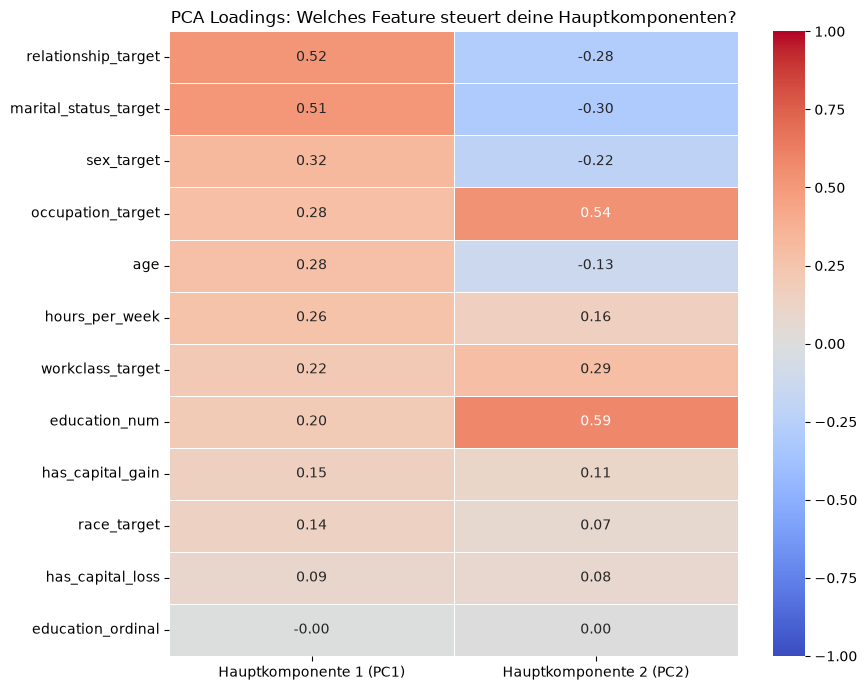

In [ ]:

# ==============================================================================
# UNABHÄNGIGE ZELLE: PCA LOADINGS FüR DIE OPTIMIERTE VERSION
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Frische Kopie vom geladenen Basis-DataFrame ziehen
loadings_df_raw = df.copy()
loadings_df_raw["income_target"] = loadings_df_raw["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# --- 2. ENCODING & PROCESSING (IDENTISCH ZUR OPTIMIERTEN PCA) ---

# Ordinal Encoding für education
loadings_df_raw["education_ordinal"] = Ordinal_Encoder(
    loadings_df_raw[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]]
)["education"]

# Target Encoding für ALLE nominalen Features (Um Sparsity zu vermeiden)
nominal_features_load = ["marital_status", "relationship", "race", "sex", "workclass", "occupation"]

target_mappings_load = Target_Encoder_Fit(
    X_train=loadings_df_raw,
    y_train=loadings_df_raw["income_target"],
    columns_to_be_encoded=nominal_features_load
)

encoded_nominal_load = Target_Encoder_Transform(
    loadings_df_raw[nominal_features_load],
    nominal_features_load,
    target_mappings_load
)

for col in nominal_features_load:
    loadings_df_raw[f"{col}_target"] = encoded_nominal_load[f"{col}_target"]

# Binarisierung der Kapitalerträge
loadings_df_raw["has_capital_gain"] = (loadings_df_raw["capital_gain"].astype(float) > 0).astype(float)
loadings_df_raw["has_capital_loss"] = (loadings_df_raw["capital_loss"].astype(float) > 0).astype(float)


# --- 3. PCA AUSFÜHREN ---
feature_columns_load = [
    "age", "education_ordinal", "education_num", "hours_per_week",
    "has_capital_gain", "has_capital_loss"
]
feature_columns_load.extend([f"{col}_target" for col in nominal_features_load])

X_load = loadings_df_raw[feature_columns_load].astype(float)
X_scaled_load = StandardScaler().fit_transform(X_load)

pca_standalone = PCA(n_components=2)
pca_standalone.fit(X_scaled_load)


# --- 4. LADUNGEN EXTRAHIEREN & PLOTTEN ---
loadings_matrix = pca_standalone.components_.T

loadings_visualization_df = pd.DataFrame(
    loadings_matrix, 
    columns=['Hauptkomponente 1 (PC1)', 'Hauptkomponente 2 (PC2)'], 
    index=feature_columns_load
)

# Sortieren nach Einfluss auf PC1 für bessere Lesbarkeit
loadings_visualization_df = loadings_visualization_df.sort_values(by='Hauptkomponente 1 (PC1)', ascending=False)

# Heatmap erstellen
plt.figure(figsize=(9, 7))
sns.heatmap(
    loadings_visualization_df, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.5
)
plt.title("PCA Loadings: Welches Feature steuert deine Hauptkomponenten?")
plt.tight_layout()
plt.show()

=== PERFORMANCE DES RANDOM FOREST ===
Test-Accuracy: 0.8239

Klassifikationsbericht:
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      4945
        >50K       0.70      0.47      0.56      1568

    accuracy                           0.82      6513
   macro avg       0.77      0.70      0.73      6513
weighted avg       0.81      0.82      0.81      6513



C:\Users\User\AppData\Local\Temp\ipykernel_17412\397587536.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances, x='Importance', y='Feature', palette='viridis')


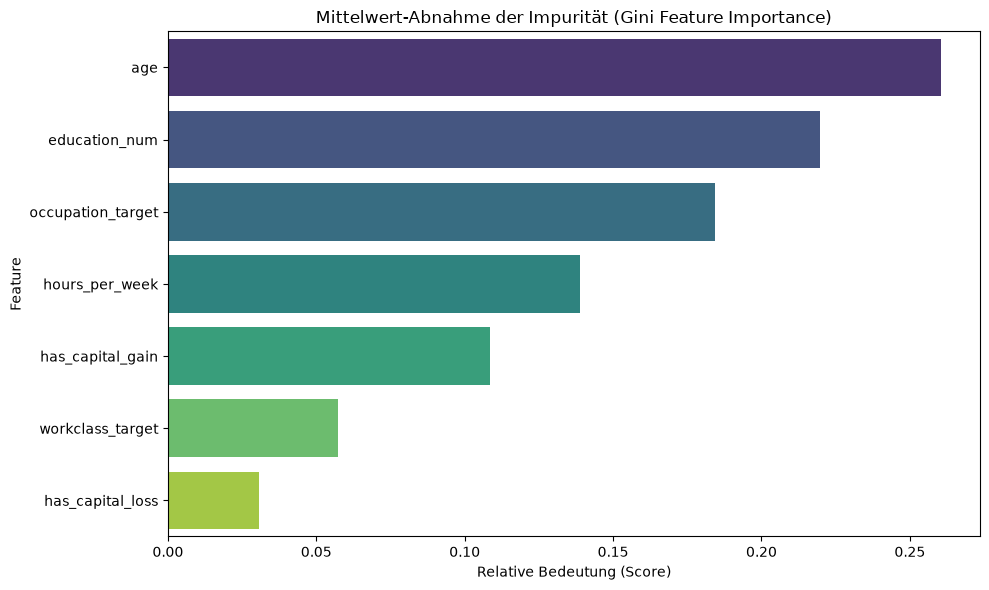

In [ ]:
#Alternativ betrachten wir einen Random Forest Classifier um die Features Importance zu verstehen

# ==============================================================================
# UNABHÄNGIGE ZELLE: RANDOM FOREST & FEATURE IMPORTANCE MODELLIERUNG
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from projectlib.alternativeEncoding import (
    Ordinal_Encoder,
    Target_Encoder_Fit,
    Target_Encoder_Transform,
)

# 1. Frische Kopie vom geladenen Basis-DataFrame ziehen
rf_df = df.copy()
rf_df["income_target"] = rf_df["income"].astype(str).str.strip().map({"<=50K": 0, ">50K": 1})

# --- 2. ENCODING & PROCESSING DIREKT IN HIER ERLEDIGEN ---

# Ordinal Encoding für education nachholen

rf_df["education_ordinal"] = Ordinal_Encoder(
    rf_df[["education"]].copy(),
    "education",
    categories_order=[["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
                      "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
                      "Prof-school", "Doctorate"]]
)["education"]

# Target Encoding für workclass und occupation nachholen
target_mappings_rf = Target_Encoder_Fit(
    X_train=rf_df,
    y_train=rf_df["income_target"],
    columns_to_be_encoded=["workclass", "occupation"]
)

encoded_target_rf = Target_Encoder_Transform(
    rf_df[["workclass", "occupation"]],
    ["workclass", "occupation"],
    target_mappings_rf
)

rf_df["workclass_target"] = encoded_target_rf["workclass_target"]
rf_df["occupation_target"] = encoded_target_rf["occupation_target"]

# Binarisierung der Kapitalerträge (Sparsity-Killer)
rf_df["has_capital_gain"] = (rf_df["capital_gain"].astype(float) > 0).astype(float)
rf_df["has_capital_loss"] = (rf_df["capital_loss"].astype(float) > 0).astype(float)


# --- 3. DATEN FÜR DAS MODELL VORBEREITEN ---
feature_columns_rf = [
    "age",  "education_num", "hours_per_week",
    "has_capital_gain", "has_capital_loss", "workclass_target", "occupation_target"
]

X_rf = rf_df[feature_columns_rf].astype(float)
y_rf = rf_df["income_target"].astype(int)

# Train-Test-Split (Gegen Overfitting)
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)


# --- 4. RANDOM FOREST TRAINIEREN ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


# --- 5. PERFORMANCE AUSGEBEN ---
y_pred = rf_model.predict(X_test)
print("=== PERFORMANCE DES RANDOM FOREST ===")
print(f"Test-Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Klassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


# --- 6. FEATURE IMPORTANCE PLOTTEN ---
importances = rf_model.feature_importances_
feature_names = X_rf.columns

rf_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances, x='Importance', y='Feature', palette='viridis')
plt.title("Mittelwert-Abnahme der Impurität (Gini Feature Importance)")
plt.xlabel("Relative Bedeutung (Score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
#mithilfe eines Random Forest Modells können wir die Feature Importance bestimmen und sehen
# welche Featues am stärksten mit dem Einkommen korrelieren, 
# s.d. wir womöglich unwichtige features für die PCA vereinfachen/ gruppieren können ohne Aussagekraft zu verlieren